# StyleGAN (cats) — FID & ResNet50 vs kimg

In [32]:
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DPI = 300
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 17,
    "legend.fontsize": 13,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "figure.titlesize": 20,
    "figure.dpi": DPI,
    "savefig.dpi": DPI,
})

ROOT = Path(".").resolve()
OUTPUTS = ROOT / "outputs_cats"


def plot_lines_vs_kimg(data, y_col, ylabel, title):
    fig, ax = plt.subplots(figsize=(10, 5), dpi=DPI)
    psi_values = sorted(data["truncation_psi"].unique())
    cmap = plt.cm.plasma
    colors = [cmap(i / max(len(psi_values) - 1, 1)) for i in range(len(psi_values))]
    for psi, color in zip(psi_values, colors):
        sub = data[data["truncation_psi"] == psi].sort_values("kimg")
        ax.plot(
            sub["kimg"], sub[y_col],
            marker="o", linewidth=2.2, markersize=7,
            color=color, label=f"psi = {psi}",
        )
    ax.set_xlabel("kimg")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(title="truncation psi", loc="best", ncol=2, framealpha=0.95)
    plt.tight_layout()
    plt.show()

## FID vs kimg


FID by training snapshot (columns = truncation psi)



,kimg,checkpoint,psi=0.1,psi=0.8,psi=0.85,psi=0.9,psi=0.95,psi=1
0,0,network-snapshot-000000.pkl,357.60,317.21,316.82,317.06,316.77,316.51
1,200,network-snapshot-000200.pkl,303.02,261.73,259.72,257.82,255.67,254.79
2,400,network-snapshot-000400.pkl,293.20,157.22,155.23,153.53,152.44,151.76
3,600,network-snapshot-000600.pkl,118.97,102.87,103.10,104.91,106.26,107.38
4,800,network-snapshot-000800.pkl,127.72,87.68,88.42,89.08,89.83,91.61
5,1000,network-snapshot-001000.pkl,137.93,74.82,75.50,77.02,78.21,79.89


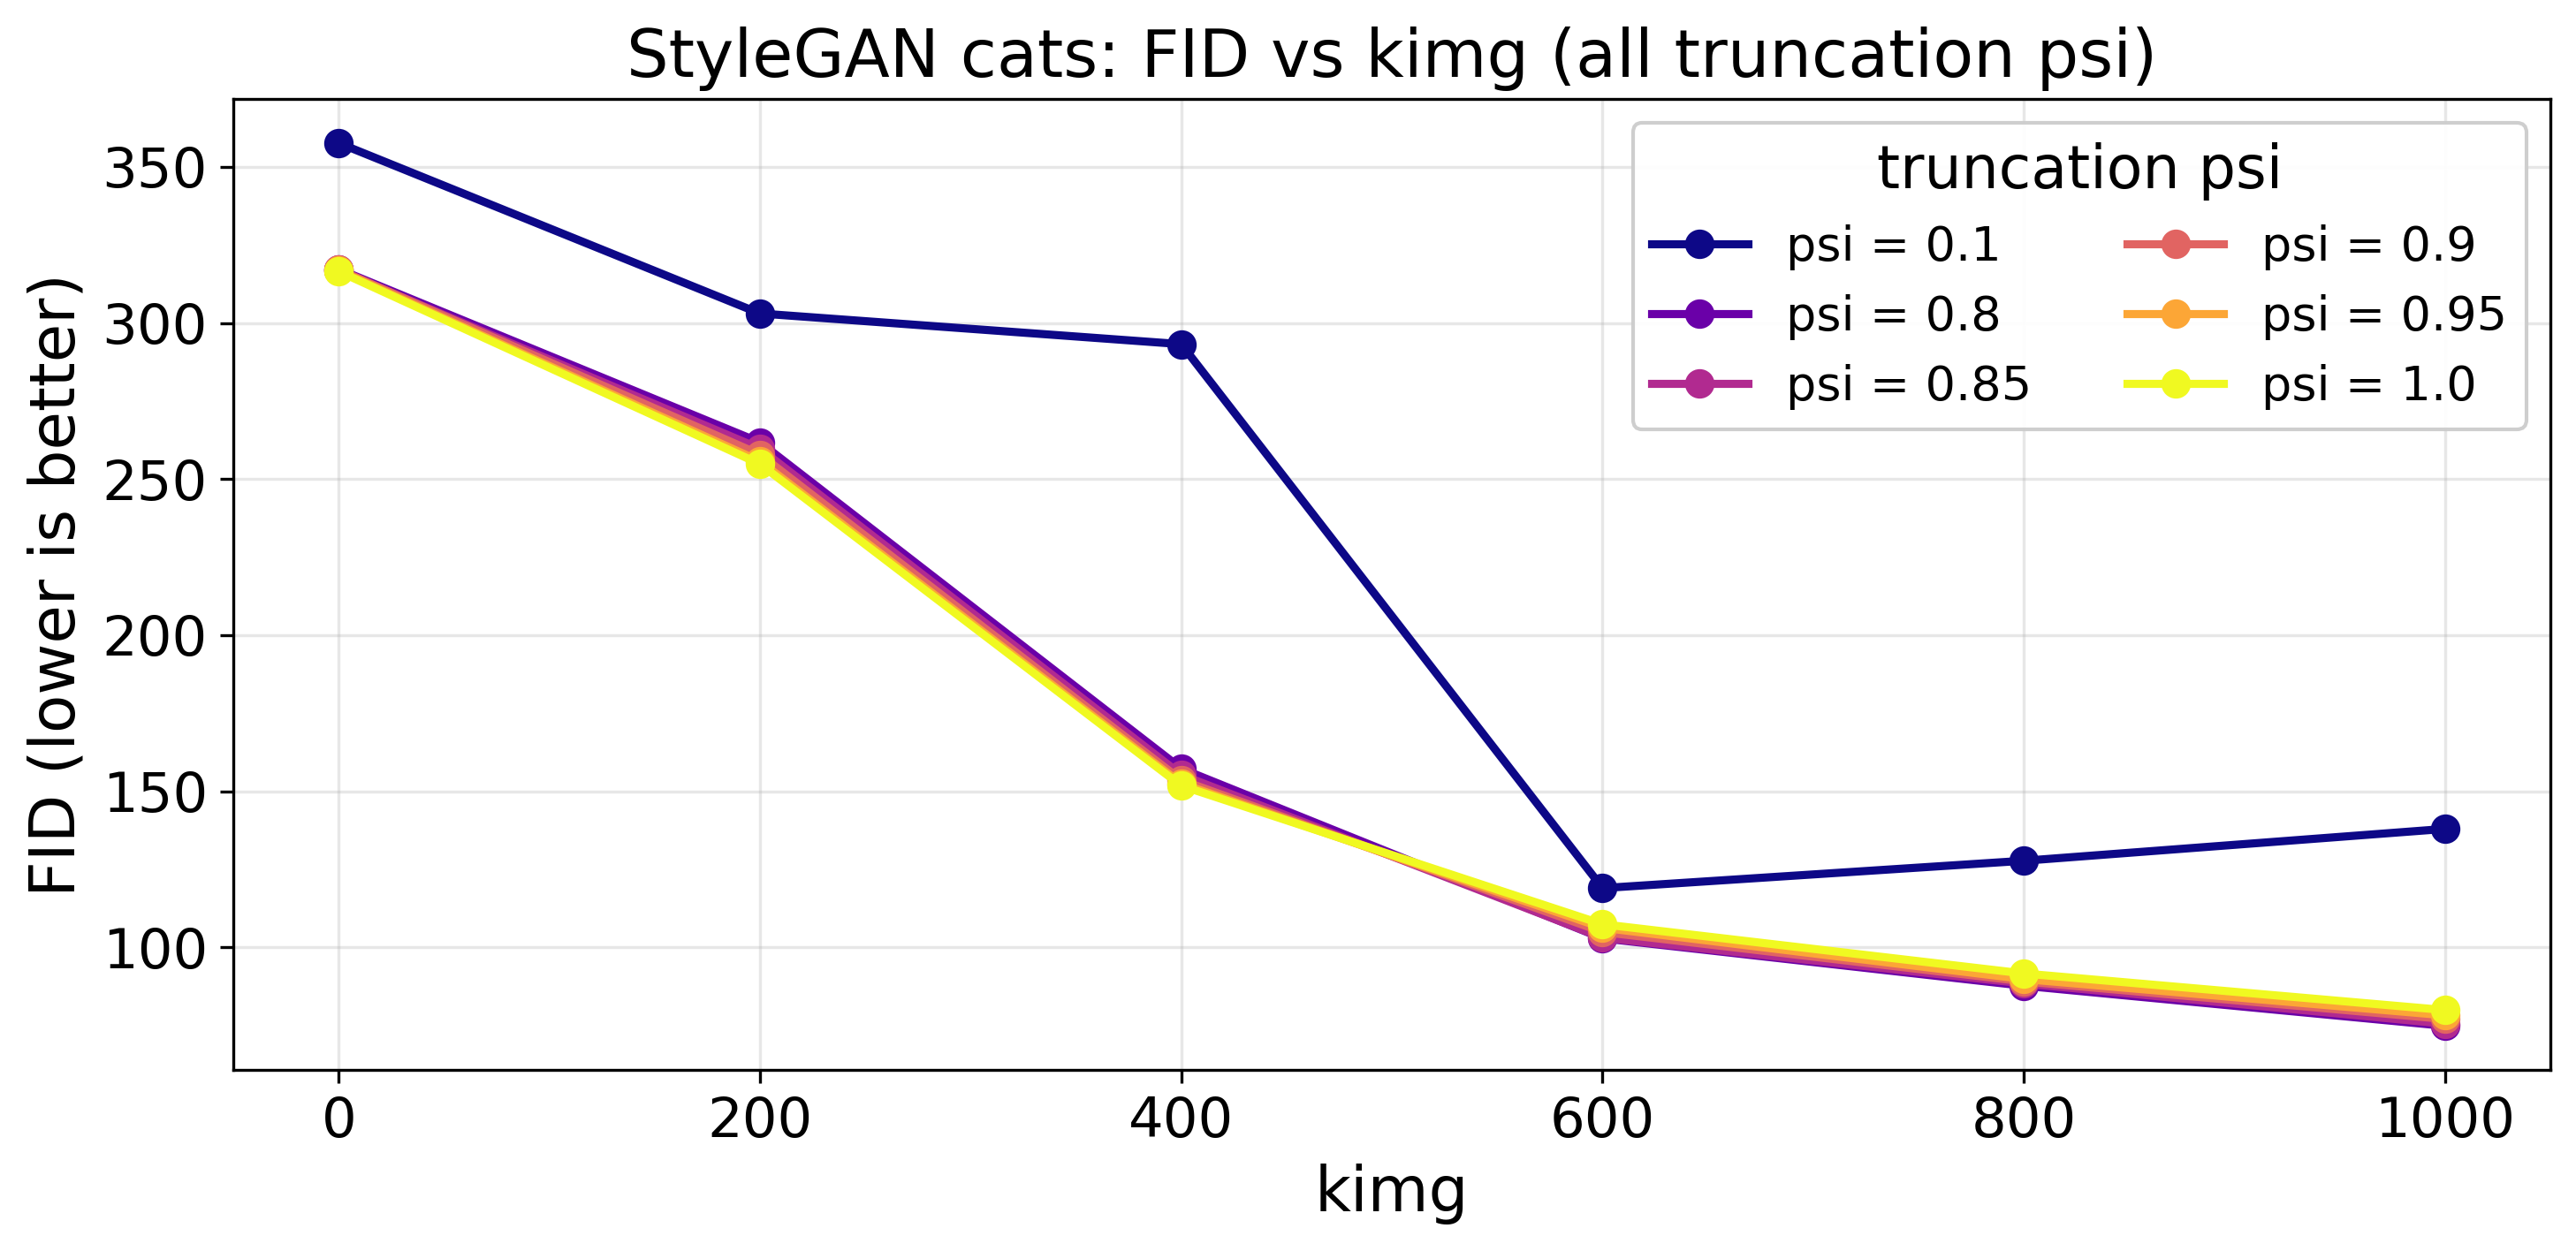

In [33]:
fid_df = pd.read_csv(OUTPUTS / "stylegan_fid_results.csv")
fid_df = fid_df.sort_values(["kimg", "truncation_psi"])

fid_wide = (
    fid_df.pivot(index="kimg", columns="truncation_psi", values="FID")
    .sort_index()
)
fid_wide.columns = [f"psi={psi:g}" for psi in fid_wide.columns]

checkpoints = (
    fid_df.drop_duplicates("kimg")
    .set_index("kimg")["checkpoint"]
)
fid_table = checkpoints.to_frame().join(fid_wide).reset_index()

print("FID by training snapshot (columns = truncation psi)\n")
display(fid_table.round(2))

plot_lines_vs_kimg(
    fid_df.sort_values(["truncation_psi", "kimg"]),
    "FID",
    "FID (lower is better)",
    "StyleGAN cats: FID vs kimg (all truncation psi)",
)

## ResNet50 cat & dog score vs kimg


In [34]:
species_files = sorted(OUTPUTS.glob("stylegan_species_score_results_psi*.csv"))
if not species_files:
    raise FileNotFoundError(f"No ResNet50 CSV in {OUTPUTS}")

parts = []
for path in species_files:
    tag = path.stem.replace("stylegan_species_score_results_psi", "")
    psi_from_name = float(tag.replace("p", "."))
    chunk = pd.read_csv(path)
    if "truncation_psi" not in chunk.columns:
        chunk["truncation_psi"] = psi_from_name
    parts.append(chunk)

species_df = pd.concat(parts, ignore_index=True).sort_values(["truncation_psi", "kimg"])
print(species_df)
print("\npsi values:", sorted(species_df["truncation_psi"].unique()))

                    checkpoint  kimg  truncation_psi  cat_score  \
0  network-snapshot-000000.pkl     0             0.9   0.000174   
1  network-snapshot-000200.pkl   200             0.9   0.002988   
2  network-snapshot-000400.pkl   400             0.9   0.358511   
3  network-snapshot-000600.pkl   600             0.9   0.560719   
4  network-snapshot-000800.pkl   800             0.9   0.664824   
5  network-snapshot-001000.pkl  1000             0.9   0.695209   

   cat_score_std  dog_score  dog_score_std  
0       0.000168   0.004189       0.003664  
1       0.024197   0.068723       0.188462  
2       0.439078   0.034723       0.128425  
3       0.429176   0.046643       0.170918  
4       0.403312   0.060874       0.197874  
5       0.391287   0.054261       0.190861  

psi values: [np.float64(0.9)]


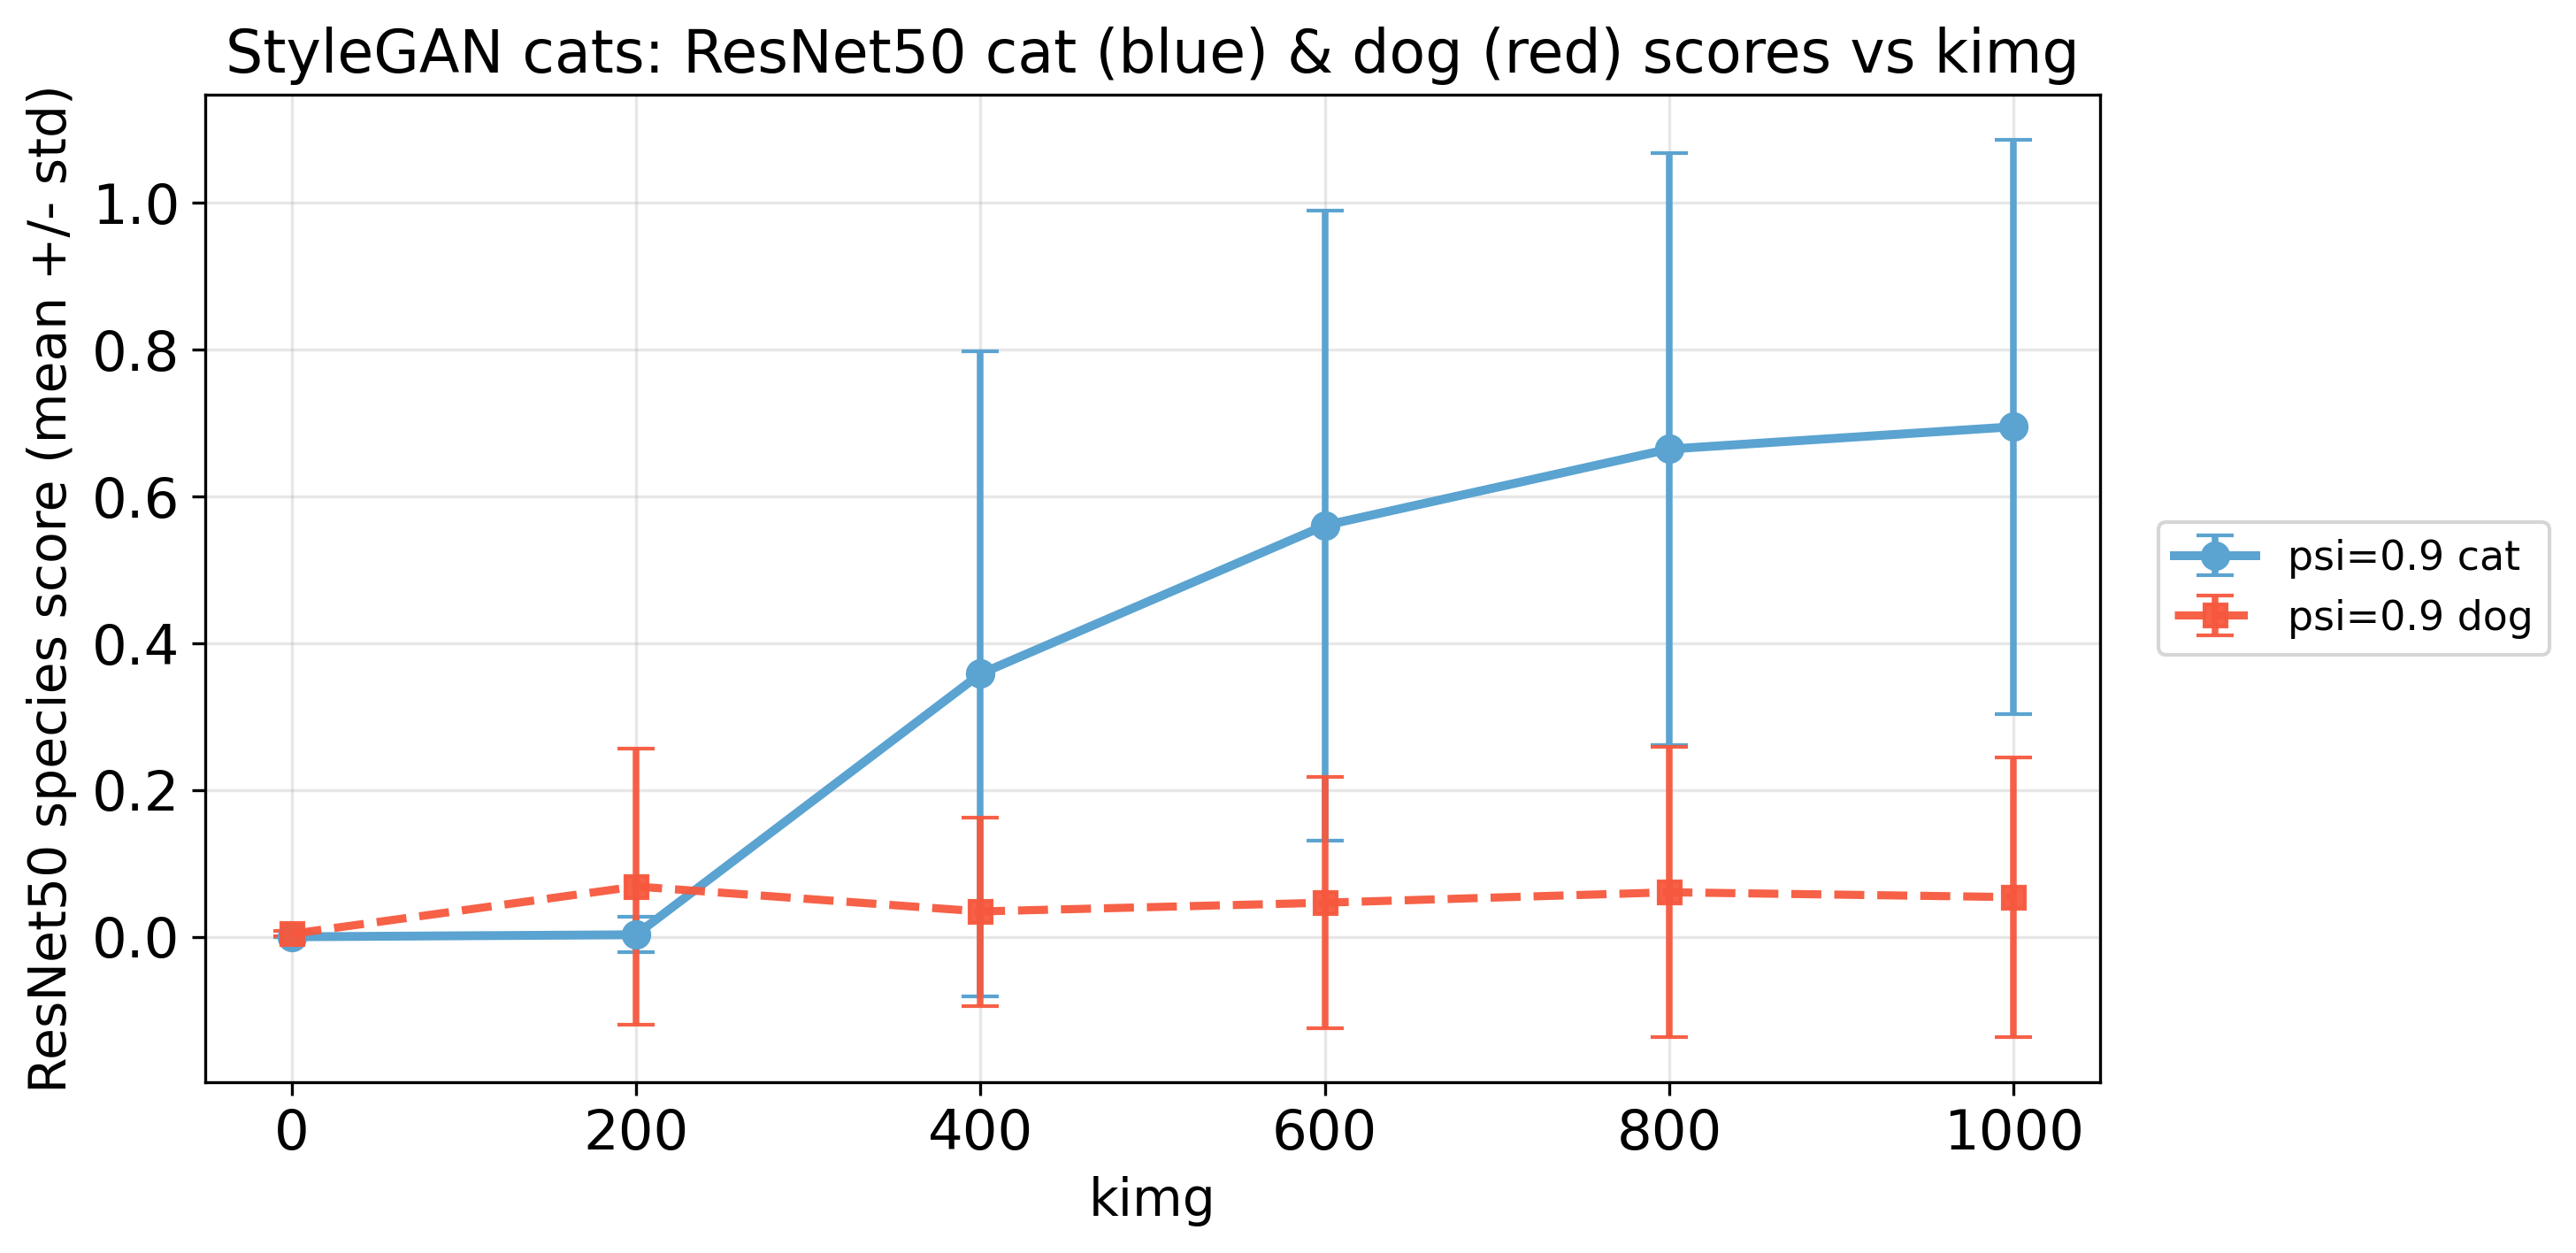

In [35]:
import numpy as np

fig, ax = plt.subplots(figsize=(10, 5), dpi=DPI)

psi_values = sorted(species_df["truncation_psi"].unique())
n_psi = len(psi_values)
cat_colors = plt.cm.Blues(np.linspace(0.55, 0.95, max(n_psi, 1)))
dog_colors = plt.cm.Reds(np.linspace(0.55, 0.95, max(n_psi, 1)))

for i, psi in enumerate(psi_values):
    sub = species_df[species_df["truncation_psi"] == psi].sort_values("kimg")
    x = sub["kimg"].to_numpy()

    ax.errorbar(
        x,
        sub["cat_score"].to_numpy(),
        yerr=sub["cat_score_std"].to_numpy(),
        marker="o",
        linewidth=2.4,
        markersize=7,
        capsize=5,
        color=cat_colors[i],
        linestyle="-",
        elinewidth=1.8,
        label=f"psi={psi} cat",
    )
    ax.errorbar(
        x,
        sub["dog_score"].to_numpy(),
        yerr=sub["dog_score_std"].to_numpy(),
        marker="s",
        linewidth=2.2,
        markersize=6,
        capsize=5,
        color=dog_colors[i],
        linestyle="--",
        alpha=0.95,
        elinewidth=1.8,
        label=f"psi={psi} dog",
    )

ax.set_xlabel("kimg", fontsize=14)
ax.set_ylabel("ResNet50 species score (mean +/- std)", fontsize=14)
ax.set_title("StyleGAN cats: ResNet50 cat (blue) & dog (red) scores vs kimg", fontsize=16)
ax.grid(True, alpha=0.3)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=11, ncol=1)
plt.tight_layout()
plt.show()